# 데이터 전처리단계

In [1]:
pip install torch torchvision numpy matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())

PyTorch version: 2.14.0
MPS available: True


In [3]:
from torchvision import datasets

train_dataset = datasets.MNIST(
    root="./data", # MNIST 데이터셋 저장할 경로
    train=True, # 학습용 데이터 가져오겠음
    download=True 
)

In [4]:
print(train_dataset)
print("데이터 갯수", len(train_dataset))
print(train_dataset[0]) # (이미지, 라벨)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
데이터 갯수 60000
(<PIL.Image.Image image mode=L size=28x28 at 0x1181702D0>, 5)


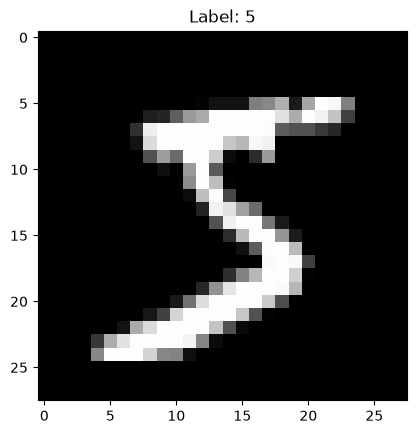

In [5]:
plt.imshow(train_dataset[0][0], cmap="gray")
plt.title(f"Label: {train_dataset[0][1]}")
plt.show()


In [6]:
from torchvision import transforms
to_tensor = transforms.ToTensor() # Tensor로 변환 + 픽셀 크기 스케일링 (0~1)
image_tensor = to_tensor(train_dataset[0][0])

print(type(train_dataset[0][0])) # <class 'PIL.Image.Image'>
print(type(image_tensor)) # <class 'torch.Tensor'>
print(image_tensor.shape) # torch.Size([1, 28, 28])
print("최솟값:", image_tensor.min()) 
print("최댓값:", image_tensor.max())


<class 'PIL.Image.Image'>
<class 'torch.Tensor'>
torch.Size([1, 28, 28])
최솟값: tensor(0.)
최댓값: tensor(1.)


In [7]:
# 한번 더 Norm 하는 이유는 가우시안 노이즈가 N(0, 1)로 들어가기 때문에,     
# 이미지도 N(0, 1)로 맞춰주기 위해서임
normalize = transforms.Normalize(
    mean=(0.5,),
    std=(0.5,)
)

normalized_image = normalize(image_tensor)

print("최솟값:", normalized_image.min())
print("최댓값:", normalized_image.max())

최솟값: tensor(-1.)
최댓값: tensor(1.)


In [8]:
# 여러 전처리 순서대로 묶어 주기
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])



In [9]:
# 전체 데이터셋 전처리 적용

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


In [10]:
# 여러 데이터 한번에 가져오기위해 DataLoader 사용

from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=128,
    shuffle=True
)

In [11]:
images, labels = next(iter(train_loader))
print(images.shape) # torch.Size([128, 1, 28, 28])
print(labels.shape) # torch.Size([128])

torch.Size([128, 1, 28, 28])
torch.Size([128])


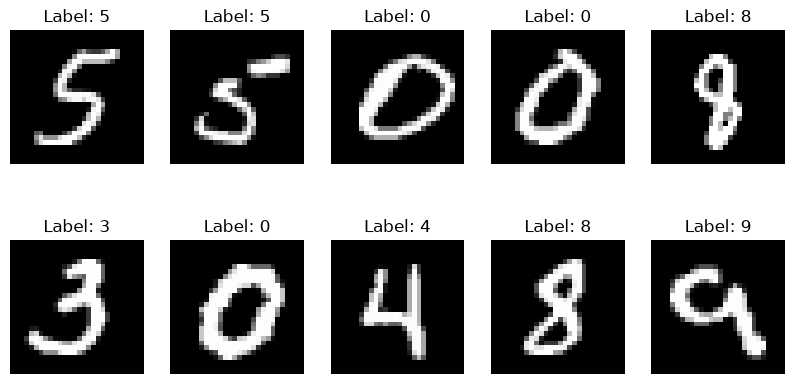

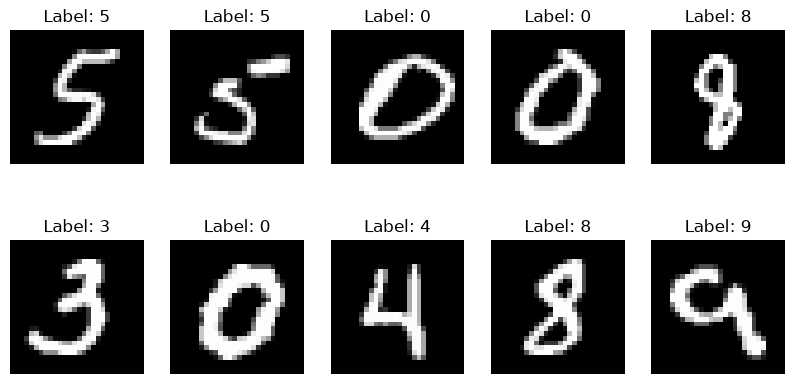

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    img = images[i].squeeze() # (1, 28, 28) -> (28, 28)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.show(0)
                      

# Forward Diffusion



In [13]:
# 이미지에 노이즈를 추가하는 과정
# 아주 작은 노이즈에서 선형적으로 증가시키는 과정

T = 1000 # 노이즈 추가하는 총 과정

beta_start = 0.0001
beta_end = 0.02 

beta = torch.linspace(beta_start, beta_end, T) # 0.0001 ~ 0.02까지 T개로 나눔
# beta_t 는 t번째 단계에서 추가되는 노이즈의 양

print(beta.shape) # torch.Size([1000])
print("처음 베타:", beta[0])
print("마지막 베타:", beta[-1])

torch.Size([1000])
처음 베타: tensor(1.0000e-04)
마지막 베타: tensor(0.0200)


In [14]:
# DDPM 논문에 따라 베타를 알파로 다시 표현

alphas = 1-beta # 특정 t에서 이전 이미지 신호를 얼마나 유지할지

print("처음 알파:", alphas[0])
print("마지막 알파:", alphas[-1])

처음 알파: tensor(0.9999)
마지막 알파: tensor(0.9800)


In [15]:
# DDPM 논문에서 X_0 -> X_t로 한번에 표현할 수 있는 식 구현
alpha_bars = torch.cumprod(alphas, dim=0) # 누적곱

print("shape:", alpha_bars.shape)
print("t=0:", alpha_bars[0])
print("t=99:", alpha_bars[99])
print("t=499:", alpha_bars[499])
print("t=999:", alpha_bars[999])

shape: torch.Size([1000])
t=0: tensor(0.9999)
t=99: tensor(0.8970)
t=499: tensor(0.0786)
t=999: tensor(4.0358e-05)


In [16]:
# 이미지 한장에 노이즈 실제로 입혀보기
x_0, label = train_dataset[0] # (이미지, 라벨)

noise = torch.randn_like(x_0)

print("x_0 shape:", x_0.shape) # torch.Size([1, 28, 28]
print("noise shape:", noise.shape) # torch.Size([1, 28, 28])

t = 500 # 노이즈 추가 단계
x_t = (
    torch.sqrt(alpha_bars[t]) * x_0 + torch.sqrt(1-alpha_bars[t]) * noise
)
print("x_t shape:", x_t.shape) # torch.Size([1, 28, 28])

x_0 shape: torch.Size([1, 28, 28])
noise shape: torch.Size([1, 28, 28])
x_t shape: torch.Size([1, 28, 28])


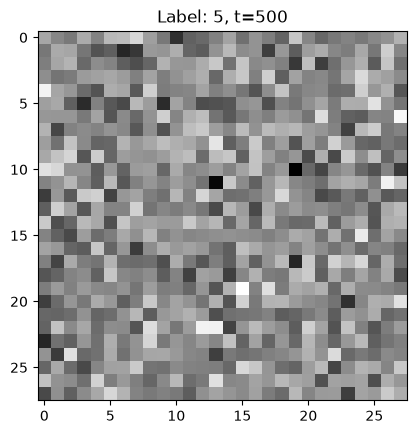

In [17]:
plt.imshow(x_t.squeeze(), cmap="gray")
plt.title(f"Label: {label}, t={t}")
plt.show()


In [18]:
# Forward Diffusion 전체 흐름

def forward_diffusion(x_0, t):
    noise = torch.randn_like(x_0)

    x_t = (
        torch.sqrt(alpha_bars[t]) * x_0 + torch.sqrt(1-alpha_bars[t]) * noise
    )
    return x_t




In [19]:
x_t = forward_diffusion(x_0, t=500)


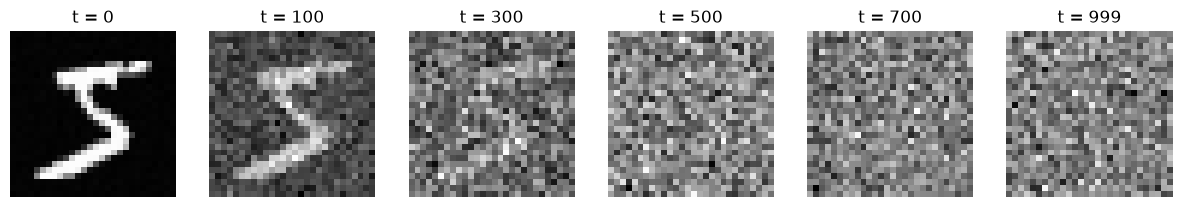

In [20]:
timesteps = [0, 100, 300, 500, 700, 999]

fig, axes = plt.subplots(1, len(timesteps), figsize=(15, 5))

for t, ax in zip(timesteps, axes):
    x_t = forward_diffusion(x_0, t)

    ax.imshow(x_t.squeeze(), cmap="gray")
    ax.set_title(f"t = {t}")
    ax.axis("off")

plt.show()

In [21]:

batch_size = images.shape[0]

t = torch.randint(
    low=0,
    high=T,
    size=(batch_size,)
) # 랜덤한 timestep 배치에 들어가있는 이미지 수 만큼

print(t.shape) # torch.Size([128])
print(t[:10]) 

torch.Size([128])
tensor([577, 647, 465, 819, 165, 275, 430, 130, 471, 173])


In [22]:
noise = torch.randn_like(images)

alpha_bar_t = alpha_bars[t].view(-1, 1, 1, 1) # (128,) -> (128, 1, 1, 1)로 변환

print("alpha_bar_t shape:", alpha_bar_t.shape) # torch.Size([128])

alpha_bar_t shape: torch.Size([128, 1, 1, 1])


In [23]:
# images       : [128, 1, 28, 28]   ← 원본 x₀
# noise        : [128, 1, 28, 28]   ← 이미지별 ε
# alpha_bar_t  : [128, 1, 1, 1]     ← 이미지별 t에 해당하는 ᾱₜ

x_t = (
    torch.sqrt(alpha_bar_t) * images + torch.sqrt(1-alpha_bar_t) * noise
)

print("x_t shape:", x_t.shape) # torch.Size([128, 1, 28, 28])

x_t shape: torch.Size([128, 1, 28, 28])


# U-Net Backbone

In [24]:
# Time Embedding 구현
import math

time_dim = 128
half_dim = time_dim/2 # 절반은 sin, 절반은 cos

freqs = torch.exp(
    -math.log(10000) * torch.arange(half_dim) / half_dim
) # t를 표현하기 위한 서로다른 주파수


print("freqs shape:", freqs.shape) # torch.Size([64])
print("freqs[:10]:", freqs[:10])

freqs shape: torch.Size([64])
freqs[:10]: tensor([1.0000, 0.8660, 0.7499, 0.6494, 0.5623, 0.4870, 0.4217, 0.3652, 0.3162,
        0.2738])


In [25]:
# t에 주파수 곱해주기

t_expanded = t[:,None] # (128,) -> (128, 1)
freqs_expanded = freqs[None,:] # (64,) -> (1, 64)

arg = t_expanded * freqs_expanded

print("arg shape:", arg.shape) # torch.Size([128, 64])

# sin, cos 적용
time_emb = torch.cat([
    torch.sin(arg),
    torch.cos(arg)
], dim=1)

print("time_emb shape:", time_emb.shape) # torch.Size([128, 128])

arg shape: torch.Size([128, 64])
time_emb shape: torch.Size([128, 128])


In [26]:
import torch.nn as nn

time_mlp = nn.Sequential(
    nn.Linear(128, 256),
    nn.SiLU(),
    nn.Linear(256,256)
)

time_emb = time_mlp(time_emb)
print("time_emb shape:", time_emb.shape) # torch.Size([128, 256])

time_emb shape: torch.Size([128, 256])


In [27]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()

        # 첫번째 이미지 특성 처리
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm1 = nn.GroupNorm(8, out_channels)

        self.time_proj = nn.Linear(
            time_dim,
            out_channels    
        )

        # 두번째 이미지 특징 처리
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm2 = nn.GroupNorm(8, out_channels)

        self.activation = nn.SiLU()

        if in_channels != out_channels:
            self.skip = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1
            )
        else: 
            self.skip = nn.Identity()



 

    def forward(self, x, time_emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = self.activation(h)

        t = self.time_proj(time_emb) # [B, time_emb_dim] -> [B, out_channels])

        t = t[:, :, None, None] # [B,C] -> [B,C,1,1]

        h = h + t

        h = self.conv2(h)
        h = self.norm2(h)
        h = self.activation(h)

        return h + self.skip(x)

In [28]:
block = ResidualBlock(
    in_channels=32,
    out_channels=64,
    time_dim=256
)

In [29]:
class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.conv = nn.Conv2d(
            channels,
            channels,
            kernel_size=4,
            stride=2,
            padding=1
        )
    def forward(self,x):
        return self.conv(x)


In [30]:
class Upsample(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.conv = nn.ConvTranspose2d(
            channels,
            channels,
            kernel_size=4,
            stride=2,
            padding=1
        )
    def forward(self,x):
        return self.conv(x)

    

In [31]:
import math
import torch
import torch.nn as nn


class TimeEmbedding(nn.Module):
    def __init__(self, emb_dim=128, time_dim=256):
        super().__init__()

        self.emb_dim = emb_dim

        self.mlp = nn.Sequential(
            nn.Linear(emb_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

    def forward(self, t):

        half_dim = self.emb_dim // 2

        freqs = torch.exp(
            -math.log(10000)
            * torch.arange(
                half_dim,
                device=t.device   # ← 반드시 이거
            )
            / half_dim
        )

        args = t[:, None].float() * freqs[None, :]

        emb = torch.cat([
            torch.sin(args),
            torch.cos(args)
        ], dim=1)


        
        return self.mlp(emb)

In [32]:
class UNet(nn.Module):
    def __init__(self, time_dim):
        super().__init__()

        # 0. Time Embedding
        self.time_embedding = TimeEmbedding(
            emb_dim=128,
            time_dim=time_dim
        )


        # 1. 입력 이미지: 1채널 -> 32채널

        self.input_conv = nn.Conv2d(
            1,32,
            kernel_size=3,
            padding=1
        )

        # 2. Encoder
        self.enc1 = ResidualBlock(32,32,time_dim)
        self.down1 = Downsample(32)

        self.enc2 = ResidualBlock(32,64,time_dim)
        self.down2 = Downsample(64)

        # 3. Bottleneck
        self.middle = ResidualBlock(64,128,time_dim)

        # 4. Decoder

        self.up1 = Upsample(128)

        # up1 : 128 Channel
        # skip1 : 64 Channel
        # concat : 192 Channel

        self.dec1 = ResidualBlock(128 + 64, 64, time_dim)

        self.up2 = Upsample(64)

        # up2: 64 Channel
        # skip1: 32 Channel
        # concat → 96 Channel

        self.dec2 = ResidualBlock(64 + 32, 32, time_dim)

        # 5. 최종 노이즈 예측
        
        self.output_conv = nn.Conv2d(
            32,1,
            kernel_size=1
        )

    def forward(self, x, t):
        time_emb = self.time_embedding(t)

        x = self.input_conv(x)

        h1 = self.enc1(x,time_emb)
        x = self.down1(h1)

        h2 = self.enc2(x,time_emb)
        x = self.down2(h2)

        x = self.middle(x, time_emb)

        x = self.up1(x)

        x = torch.cat([x,h2], dim=1)

        x = self.dec1(x,time_emb)

        x = self.up2(x)

        x = torch.cat([x,h1], dim=1)
        x = self.dec2(x, time_emb)

        x = self.output_conv(x)

        return x
    



        

In [33]:
model = UNet(time_dim=256)


In [34]:
pred_noise = model(x_t,t)
print(pred_noise.shape)

torch.Size([128, 1, 28, 28])


# Loss optimizer


In [35]:
import torch.nn.functional as F

loss = F.mse_loss(pred_noise, noise)

print("Loss", loss.item())

Loss 1.1283212900161743


In [36]:
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)
print("device", device)

model = model.to(device)
alpha_bars = alpha_bars.to(device)

device mps


In [37]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [38]:
print("model :", next(model.parameters()).device)
print("x_t   :", x_t.device)
print("t     :", t.device)
print("noise :", noise.device)

model : mps:0
x_t   : cpu
t     : cpu
noise : cpu


In [42]:
loss_history = []
epochs = 10

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for images, _ in train_loader:
        images = images.to(device)

        batch_size = images.shape[0]

        t = torch.randint(
            0,T,(batch_size,),device=device
        )

        noise = torch.randn_like(images)

        alpha_bar_t = alpha_bars[t].view(-1,1,1,1)

        x_t = (torch.sqrt(alpha_bar_t)*images + torch.sqrt(1-alpha_bar_t)*noise)

        pred_noise = model(x_t,t)

        loss = F.mse_loss(pred_noise, noise)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss = total_loss + loss.item()

    avg_loss = total_loss / len(train_loader)

    loss_history.append(avg_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {avg_loss:.4f}"
        )
    print(f"Epoch [{epoch}/10] Loss: {loss:.4f}")

Epoch [1/10] Loss: 0.0243
Epoch [0/10] Loss: 0.0270
Epoch [2/10] Loss: 0.0239
Epoch [1/10] Loss: 0.0227
Epoch [3/10] Loss: 0.0236
Epoch [2/10] Loss: 0.0234
Epoch [4/10] Loss: 0.0235
Epoch [3/10] Loss: 0.0269
Epoch [5/10] Loss: 0.0230
Epoch [4/10] Loss: 0.0273
Epoch [6/10] Loss: 0.0233
Epoch [5/10] Loss: 0.0231
Epoch [7/10] Loss: 0.0234
Epoch [6/10] Loss: 0.0236
Epoch [8/10] Loss: 0.0232
Epoch [7/10] Loss: 0.0243
Epoch [9/10] Loss: 0.0229
Epoch [8/10] Loss: 0.0169
Epoch [10/10] Loss: 0.0231
Epoch [9/10] Loss: 0.0228


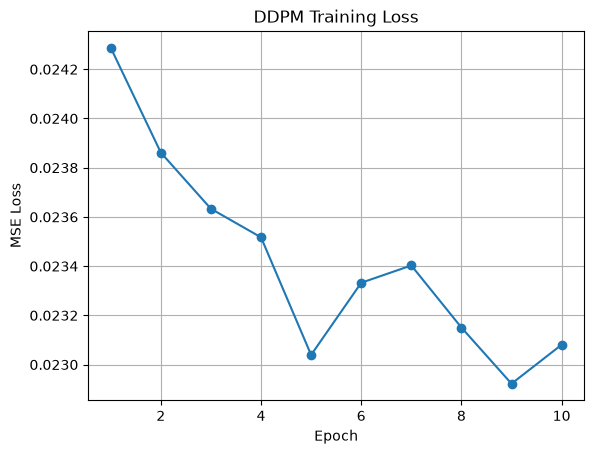

In [43]:
plt.plot(
    range(1, len(loss_history) + 1),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("DDPM Training Loss")
plt.grid()

plt.show()

# Reverse Diffusion

In [46]:
@torch.no_grad()
def reverse_step(model, x_t, t):

    batch_size = x_t.shape[0]

    # 현재 timestep을 batch 크기로 생성
    t_batch = torch.full(
        (batch_size,),
        t,
        device=x_t.device,
        dtype=torch.long
    )

    # 모델이 현재 x_t에 포함된 noise 예측
    pred_noise = model(x_t, t_batch)

    # 현재 timestep의 값들
    beta_t = beta[t]
    alpha_t = alphas[t]
    alpha_bar_t = alpha_bars[t]

    # reverse mean 계산
    mean = (
        1 / torch.sqrt(alpha_t)
    ) * (
        x_t
        -
        (beta_t / torch.sqrt(1 - alpha_bar_t))
        * pred_noise
    )

    # 마지막 t=0에서는 noise를 추가하지 않음
    if t == 0:
        return mean

    # DDPM의 stochastic noise
    noise = torch.randn_like(x_t)

    # posterior variance
    alpha_bar_prev = alpha_bars[t - 1]

    posterior_variance = (
        beta_t
        * (1 - alpha_bar_prev)
        / (1 - alpha_bar_t)
    )

    return mean + torch.sqrt(posterior_variance) * noise


    

In [47]:
betas = beta.to(device)
alphas = alphas.to(device)
alpha_bars = alpha_bars.to(device)

In [48]:
num_samples = 16

x = torch.randn(
    num_samples,
    1,
    28,
    28,
    device=device
)

print(x.shape)

torch.Size([16, 1, 28, 28])


In [49]:
model.eval()

samples = {}

x = torch.randn(
    16,
    1,
    28,
    28,
    device=device
)

save_steps = [999, 750, 500, 250, 100, 0]

for t in reversed(range(T)):

    x = reverse_step(
        model,
        x,
        t
    )

    if t in save_steps:
        samples[t] = x.detach().cpu()

In [50]:
print(samples.keys())
print(samples[0].shape)

dict_keys([999, 750, 500, 250, 100, 0])
torch.Size([16, 1, 28, 28])


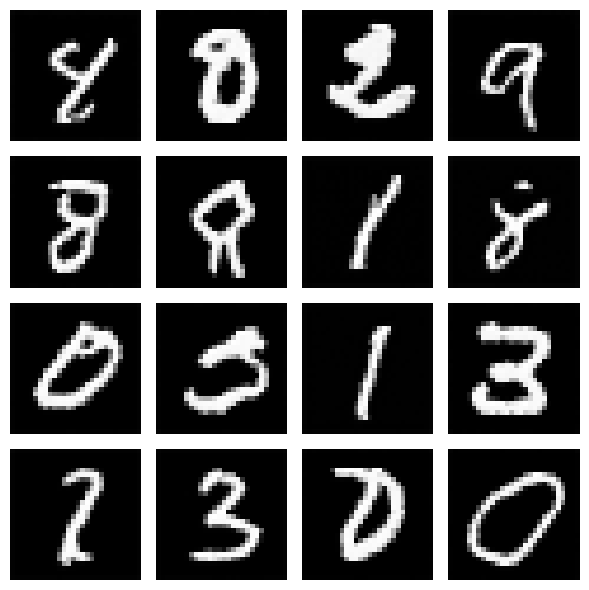

In [51]:
final_images = samples[0]

final_images = (
    final_images.clamp(-1, 1) + 1
) / 2

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(
        final_images[i, 0],
        cmap="gray"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

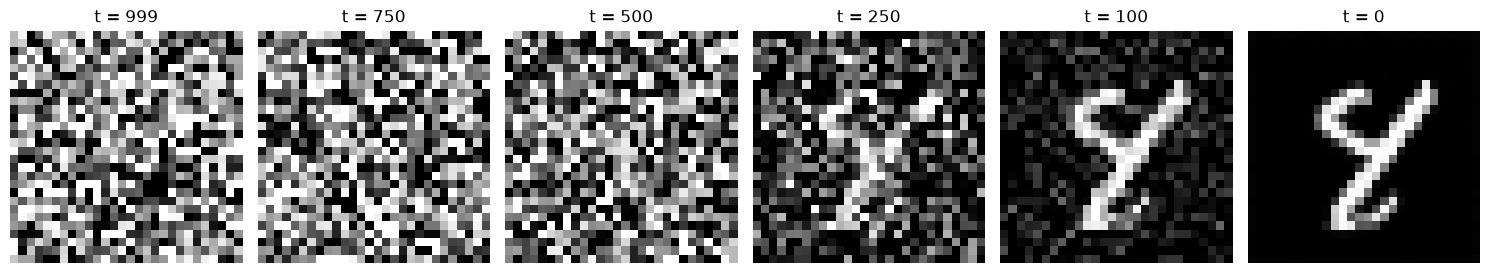

In [52]:
save_steps = [999, 750, 500, 250, 100, 0]

fig, axes = plt.subplots(
    1,
    len(save_steps),
    figsize=(15, 3)
)

sample_idx = 0

for ax, step in zip(axes, save_steps):

    img = samples[step][sample_idx]

    img = (
        img.clamp(-1, 1) + 1
    ) / 2

    ax.imshow(
        img[0],
        cmap="gray"
    )

    ax.set_title(f"t = {step}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [53]:
torch.save(
    model.state_dict(),
    "ddpm_baseline.pth"
)

In [54]:
# 비교할 초기 노이즈 동일하게 유지

num_samples = 16

initial_noise = torch.randn(
    num_samples,
    1,
    28,
    28,
    device=device
)

print(initial_noise.shape)

torch.Size([16, 1, 28, 28])


In [55]:
torch.save(
    initial_noise.cpu(),
    "initial_noise.pt"
)


In [56]:
@torch.no_grad()
def sample_ddpm(model, initial_noise):

    model.eval()

    # 원본 initial_noise를 건드리지 않기 위해 clone
    x = initial_noise.clone().to(device)

    for t in reversed(range(T)):
        x = reverse_step(
            model,
            x,
            t
        )

    return x

In [57]:
baseline_samples = sample_ddpm(
    model,
    initial_noise
)


In [58]:
torch.save(
    baseline_samples.cpu(),
    "baseline_samples.pt"
)

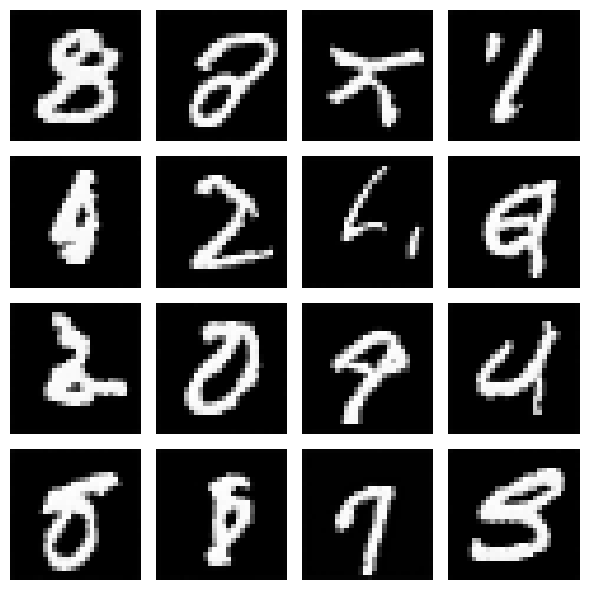

In [59]:
images = (
    baseline_samples
    .detach()
    .cpu()
    .clamp(-1, 1)
    + 1
) / 2

fig, axes = plt.subplots(
    4,
    4,
    figsize=(6, 6)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        images[i, 0],
        cmap="gray"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

# Reward Model

In [64]:
class RewardModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1,32,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self,x):
        x = self.features(x)
        return self.classifier(x)

    

In [65]:
reward_model = RewardModel().to(device)

reward_optimizer = torch.optim.Adam(
    reward_model.parameters(),
    lr = 1e-3
)

In [66]:
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

In [67]:
reward_epochs = 5

for epoch in range(reward_epochs):
    reward_model.train()

    train_loss=0
    correct=0
    total=0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = reward_model(images)

        loss = F.cross_entropy(logits, labels)

        reward_optimizer.zero_grad()
        loss.backward()
        reward_optimizer.step()

        train_loss += loss.item()

        predictions = logits.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(train_loader)

    accuracy = correct / total

    print(
        f"Epoch [{epoch+1}/{reward_epochs}] "
        f"Loss: {avg_loss:.4f} "
        f"Accuracy: {accuracy:.4f}"
    )

Epoch [1/5] Loss: 0.0231 Accuracy: 0.9423
Epoch [2/5] Loss: 0.0231 Accuracy: 0.9846
Epoch [3/5] Loss: 0.0231 Accuracy: 0.9885
Epoch [4/5] Loss: 0.0231 Accuracy: 0.9920
Epoch [5/5] Loss: 0.0231 Accuracy: 0.9935


In [68]:
reward_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        logits = reward_model(images)

        predictions = logits.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

test_accuracy = correct / total

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)


Test Accuracy: 0.9896


In [69]:
torch.save(
    reward_model.state_dict(),
    "mnist_reward_model.pth"
)

In [70]:
reward_model.eval()

for param in reward_model.parameters():
    param.requires_grad = False

In [71]:
@torch.no_grad()
def get_reward(images):

    logits = reward_model(images)

    probs = torch.softmax(
        logits,
        dim=1
    )

    rewards, predicted_classes = probs.max(
        dim=1
    )

    return rewards, predicted_classes

In [72]:
rewards, classes = get_reward(
    baseline_samples
)

print("Classes :", classes)
print("Rewards :", rewards)
print("Average :", rewards.mean())

Classes : tensor([8, 2, 7, 1, 6, 2, 4, 9, 2, 0, 9, 4, 8, 5, 7, 3], device='mps:0')
Rewards : tensor([1.0000, 0.8566, 0.7026, 0.9999, 0.8611, 1.0000, 0.9293, 0.9294, 1.0000,
        0.9637, 0.9982, 0.9992, 0.6971, 0.3826, 0.9995, 0.8653],
       device='mps:0')
Average : tensor(0.8865, device='mps:0')
